In [1]:
# Set up the file path
import os
os.chdir('..')

Combinatorial Sampling Test: Picking 3 from 5 (Mocking 1 parameters)
Total Unique Combinations: 10
Expected Probability per combination: 0.1000
Running 20000 simulations for each policy...

Displaying Comparison Plot...


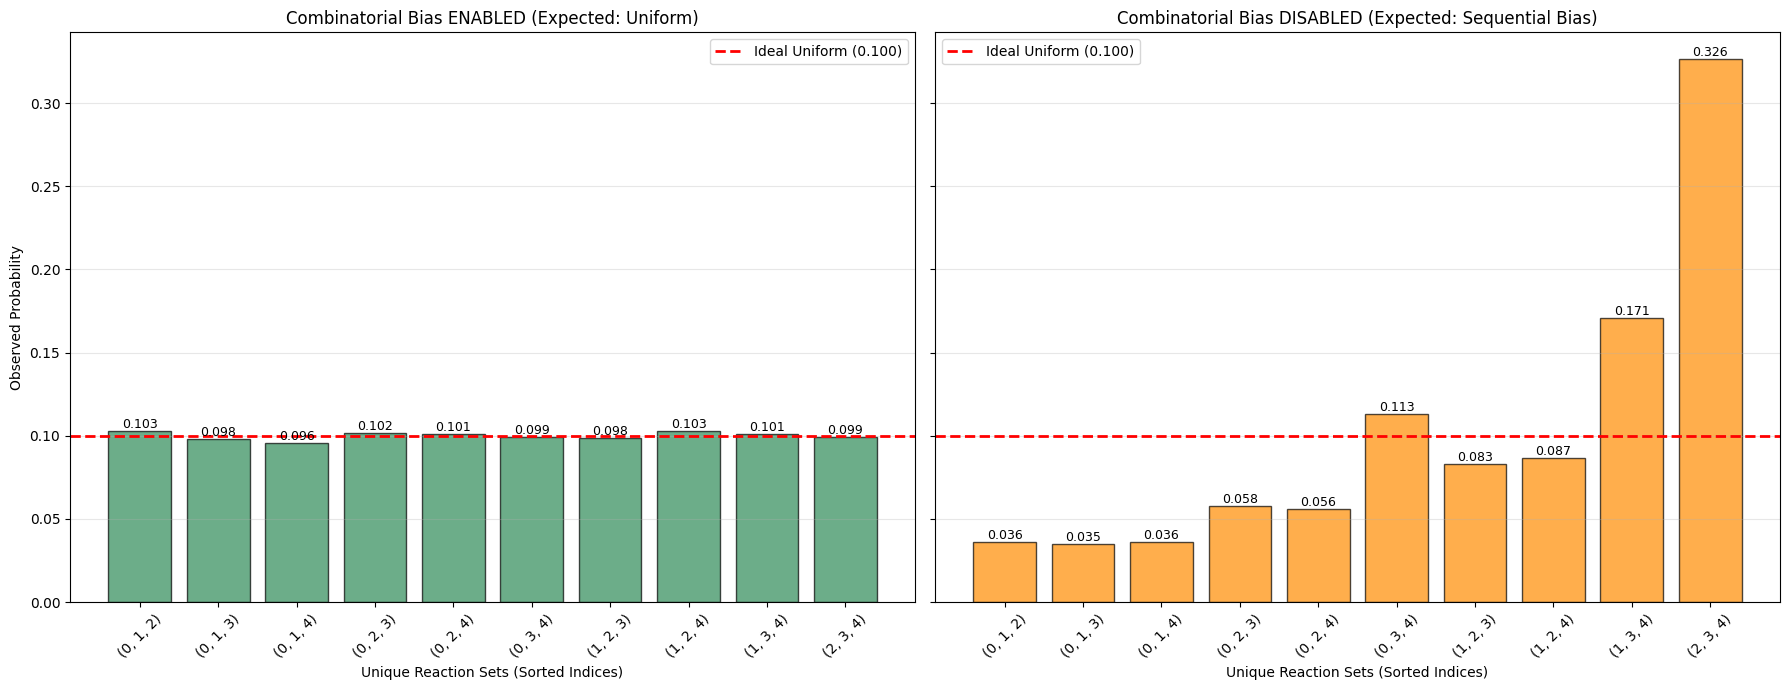


STATISTICAL ANALYSIS (Chi-Squared Test)
Policy: Combinatorial Bias ENABLED
Chi2: 9.3870, P-Value: 0.4023
✅ SUCCESS: Distribution is UNIFORM (P > 0.05).
----------------------------------------
Policy: Combinatorial Bias DISABLED
Chi2: 14608.7410, P-Value: 0.0000
✅ SUCCESS: Distribution is BIASED (P <= 0.05 - This is the expected result).


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math
from scipy.stats import chisquare

# ==========================================
# 1. Imports from User's Library and Mocks
# ==========================================

# NOTE: The following line assumes the policy is installed in your RL4CRN environment.
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex

class DummyModule(nn.Module):
    """ 
    PyTorch module that always returns zeros, used for mocking the policy's 
    Encoder and Reaction Structure Head, and Parameter Generators.
    
    Note: For parameter generators, it must return 3 elements: samples, log_probs, entropies.
    """
    def __init__(self, output_shape, is_parameter_head=False):
        super().__init__()
        self.output_shape = output_shape
        self.is_parameter_head = is_parameter_head

    def forward(self, x, **kwargs):
        # We assume batch size of 1 for this test
        out = torch.zeros(x.shape[0], *self.output_shape[1:])
        
        if self.is_parameter_head:
            # For parameter heads, return samples, log_probabilities, and entropies
            # Log_probs and entropies are scalar (0.0), samples must be the output tensor
            return out, torch.zeros(x.shape[0]), torch.zeros(x.shape[0])
        else:
            # For Encoder or Structure Head, just return the output tensor
            return out

# ==========================================
# 2. Test Configuration & Execution
# ==========================================

def run_simulation(policy, M, K, NUM_SIMULATIONS):
    """ Executes the Monte Carlo simulation for a given policy. """
    final_sets = []
    
    for _ in range(NUM_SIMULATIONS):
        policy.reset_template()
        # Initialize state tensor with correct shape (Batch_size, M)
        # Note: The policy needs the full state shape (M + P + I)
        state = torch.zeros(1, policy.M + policy.P + policy.I)
        current_set = []
        for step in range(K):
            with torch.no_grad():
                # We expect the imported policy's forward pass to use its mocked NN heads
                actions, _, _ = policy(state, mode='full')
            
            # Use Python int for clean labels (avoiding np.int64)
            r_idx = int(actions[0]['reaction index'])
            
            # Update state with the selected reaction (first M elements are reaction indicators)
            state[0, r_idx] = 1.0
            
            current_set.append(r_idx)
        current_set.sort()
        final_sets.append(tuple(current_set))
        
    return final_sets

def run_test():
    # Config
    M = 5              # Library Size (Total reactions available)
    K = 3              # Target Set Size (Reactions to pick)
    NUM_SIMULATIONS = 20000
    
    # Use 1 continuous parameter. This is necessary to force the action block 
    # inside the policy to handle continuous parameters, preventing the NoneType error.
    P_CONT = 1
    P_DISC = 0
    P_TOTAL = P_CONT + P_DISC
    
    total_combinations = math.comb(M, K)
    expected_prob = 1 / total_combinations
    
    print("="*40)
    print(f"Combinatorial Sampling Test: Picking {K} from {M} (Mocking {P_TOTAL} parameters)")
    print(f"Total Unique Combinations: {total_combinations}")
    print(f"Expected Probability per combination: {expected_prob:.4f}")
    print("="*40)

    # Helper function to create policy instance and inject mocks
    def create_policy(bias_enabled):
        
        # --- FIX 1: Provide default attributes required by AddReactionByIndex base class ---
        default_nn_attributes = {
            "hidden_size": 32, 
            "num_layers": 2    
        }
        
        # Create policy instance, setting num_parameters=P_TOTAL to satisfy its constructor.
        policy = AddReactionByOrderedIndex(
            num_reactions=M, 
            num_parameters=P_TOTAL, 
            num_inputs=0, 
            encoder_attributes=default_nn_attributes, 
            deep_layer_size=16, 
            structure_head_attributes=default_nn_attributes, 
            parameter_head_attributes=default_nn_attributes, 
            input_influence_head_attributes=default_nn_attributes, 
            target_set_size=K, masks=None, device='cpu', 
            entropy_weights_per_head={'structure': 1.0, 'continuous': 0.0, 'discrete': 0.0, 'input_influence': 0.0},
            combinatorial_bias_enabled=bias_enabled
        )
        
        # Inject Mocks for Structure (Always necessary for this test)
        policy.encoder = DummyModule((1, 16))
        policy.reaction_structure_head = DummyModule((1, M))
        
        # --- CRITICAL FIX: Manually inject/overwrite the continuous parameter generator ---
        # This guarantees policy.continuous_parameter_generator is not None, 
        # forcing the execution path that assigns samples_continuous_parameters to a tensor.
        policy.continuous_parameter_generator = DummyModule((1, P_CONT), is_parameter_head=True)
        # Also ensure mask is set for the slicing logic later in the policy.
        policy.continuous_parameter_mask = torch.ones(M, P_CONT)
        
        # Handle discrete generator if P_DISC > 0 (currently 0, so skips)
        if P_DISC > 0 and policy.discrete_parameter_generator:
             policy.discrete_parameter_generator = DummyModule((1, P_DISC), is_parameter_head=True)
             policy.discrete_parameter_mask = torch.ones(M, P_DISC)
             
        # Update P, M, K attributes on the policy instance for use in run_simulation state calculation
        policy.P = P_TOTAL
        policy.M = M
        policy.K = K
        policy.I = 0 # Ensure I is 0 as set in constructor

        return policy

    # --- POLICY 1: Combinatorial Bias ENABLED (Expected Uniform) ---
    policy_uniform = create_policy(bias_enabled=True)

    # --- POLICY 2: Combinatorial Bias DISABLED (Expected Sequential Bias) ---
    policy_biased = create_policy(bias_enabled=False)


    # Run Simulations
    print(f"Running {NUM_SIMULATIONS} simulations for each policy...")
    sets_uniform = run_simulation(policy_uniform, M, K, NUM_SIMULATIONS)
    sets_biased = run_simulation(policy_biased, M, K, NUM_SIMULATIONS)

    # --- Analysis & Plotting ---
    
    # Analyze Uniform Results
    counts_uniform = Counter(sets_uniform)
    all_keys = sorted(list(set(sets_uniform) | set(sets_biased))) # Get all keys for consistent plotting
    
    freq_uniform = [counts_uniform.get(k, 0) / NUM_SIMULATIONS for k in all_keys]
    
    # Analyze Biased Results
    counts_biased = Counter(sets_biased)
    freq_biased = [counts_biased.get(k, 0) / NUM_SIMULATIONS for k in all_keys]
    
    labels = [str(k) for k in all_keys]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    
    # Plot 1: Uniform (Enabled Bias)
    ax = axes[0]
    bars_uniform = ax.bar(labels, freq_uniform, color='seagreen', edgecolor='black', alpha=0.7)
    ax.axhline(y=expected_prob, color='red', linestyle='--', linewidth=2, label=f'Ideal Uniform ({expected_prob:.3f})')
    ax.set_xlabel("Unique Reaction Sets (Sorted Indices)")
    ax.set_ylabel("Observed Probability")
    ax.set_title("Combinatorial Bias ENABLED (Expected: Uniform)")
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for bar, freq in zip(bars_uniform, freq_uniform):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{freq:.3f}', 
                ha='center', va='bottom', fontsize=9)

    # Plot 2: Biased (Disabled Bias)
    ax = axes[1]
    bars_biased = ax.bar(labels, freq_biased, color='darkorange', edgecolor='black', alpha=0.7)
    ax.axhline(y=expected_prob, color='red', linestyle='--', linewidth=2, label=f'Ideal Uniform ({expected_prob:.3f})')
    ax.set_xlabel("Unique Reaction Sets (Sorted Indices)")
    ax.set_title("Combinatorial Bias DISABLED (Expected: Sequential Bias)")
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for bar, freq in zip(bars_biased, freq_biased):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{freq:.3f}', 
                ha='center', va='bottom', fontsize=9)
    
    print("\nDisplaying Comparison Plot...")
    plt.tight_layout()
    plt.show()

    # --- Statistical Test ---
    print("\n" + "="*40)
    print("STATISTICAL ANALYSIS (Chi-Squared Test)")
    print("="*40)

    # Test 1: Uniform Policy
    observed_uniform = [counts_uniform.get(k, 0) for k in all_keys]
    expected = [NUM_SIMULATIONS * expected_prob] * len(all_keys)
    
    chi2_uniform, p_value_uniform = chisquare(observed_uniform, f_exp=expected)
    print(f"Policy: Combinatorial Bias ENABLED")
    print(f"Chi2: {chi2_uniform:.4f}, P-Value: {p_value_uniform:.4f}")
    if p_value_uniform > 0.05:
        print("✅ SUCCESS: Distribution is UNIFORM (P > 0.05).")
    else:
        print("❌ WARNING: Distribution shows statistical bias (P <= 0.05).")
    
    print("-" * 40)

    # Test 2: Biased Policy
    observed_biased = [counts_biased.get(k, 0) for k in all_keys]
    chi2_biased, p_value_biased = chisquare(observed_biased, f_exp=expected)
    print(f"Policy: Combinatorial Bias DISABLED")
    print(f"Chi2: {chi2_biased:.4f}, P-Value: {p_value_biased:.4f}")
    if p_value_biased < 0.05:
        print("✅ SUCCESS: Distribution is BIASED (P <= 0.05 - This is the expected result).")
    else:
        print("❌ WARNING: Distribution appears UNIFORM (P > 0.05 - Unexpected result).")
    
if __name__ == "__main__":
    run_test()